# Machine Learning Capstone Project: Classification Track
## Section A - Dataset & EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.neural_network import MLPClassifier
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

# Set aesthetic parameters
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2');


### A1 Dataset Loading & Audit

In [2]:
# Load the dataset
df = pd.read_csv('../data/water_potability_classsification.csv')

print(f"Dataset Shape: {df.shape}")
df.info()
display(df.head())
print("\nMissing Value Counts:\n", df.isnull().sum().sort_values(ascending=False))

target = 'Potability'
print(f"\nTarget '{target}' distribution:\n", df[target].value_counts(normalize=True))


Dataset Shape: (3276, 10)
<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0



Missing Value Counts:
 Sulfate            781
ph                 491
Trihalomethanes    162
Hardness             0
Chloramines          0
Solids               0
Conductivity         0
Organic_carbon       0
Turbidity            0
Potability           0
dtype: int64

Target 'Potability' distribution:
 Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64


### Insight Commentary: Dataset Audit
**Audit Observations:**
- Dataset predicts water potability (0 = not potable, 1 = potable).
- Target distribution is slightly imbalanced.
- Several features (like ph, Sulfate, Trihalomethanes) contain missing values which require imputation.


### A2 EDA Visualizations

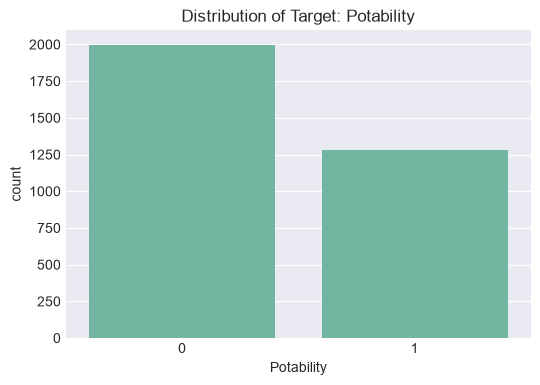

In [3]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=df)
plt.title('Distribution of Target: Potability')
plt.show()


### Insight Commentary: Target Distribution
**Visual Insights:**
- The distribution shows the classes (potable vs. non-potable) are slightly imbalanced, which is common in real-world water quality datasets.

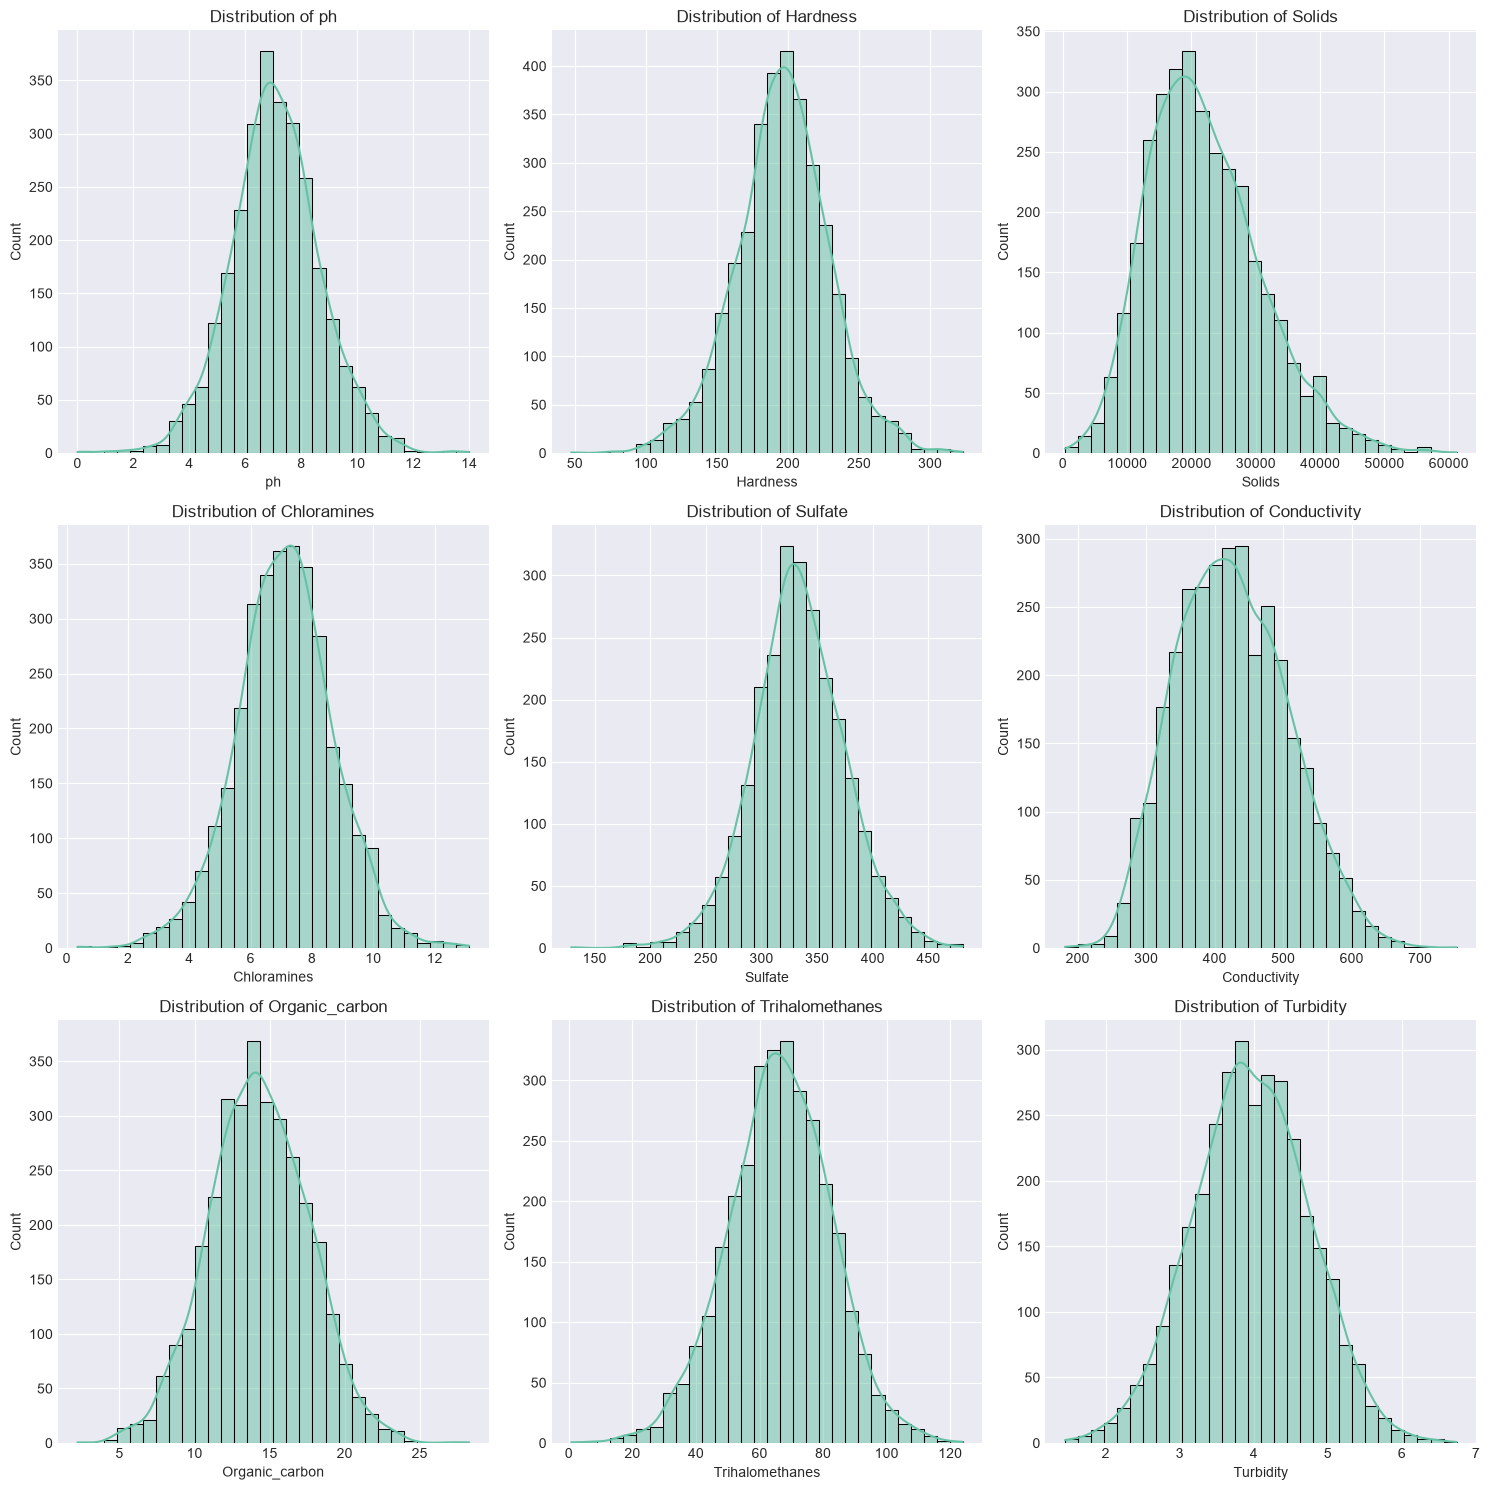

In [4]:
# Feature Distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()
features = df.columns.drop(target)
for idx, feature in enumerate(features):
    sns.histplot(df[feature].dropna(), bins=30, kde=True, ax=axes[idx])
    axes[idx].set_title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()


### Insight Commentary: Feature Distributions
**Visual Insights:**
- Most features exhibit a near-normal distribution.

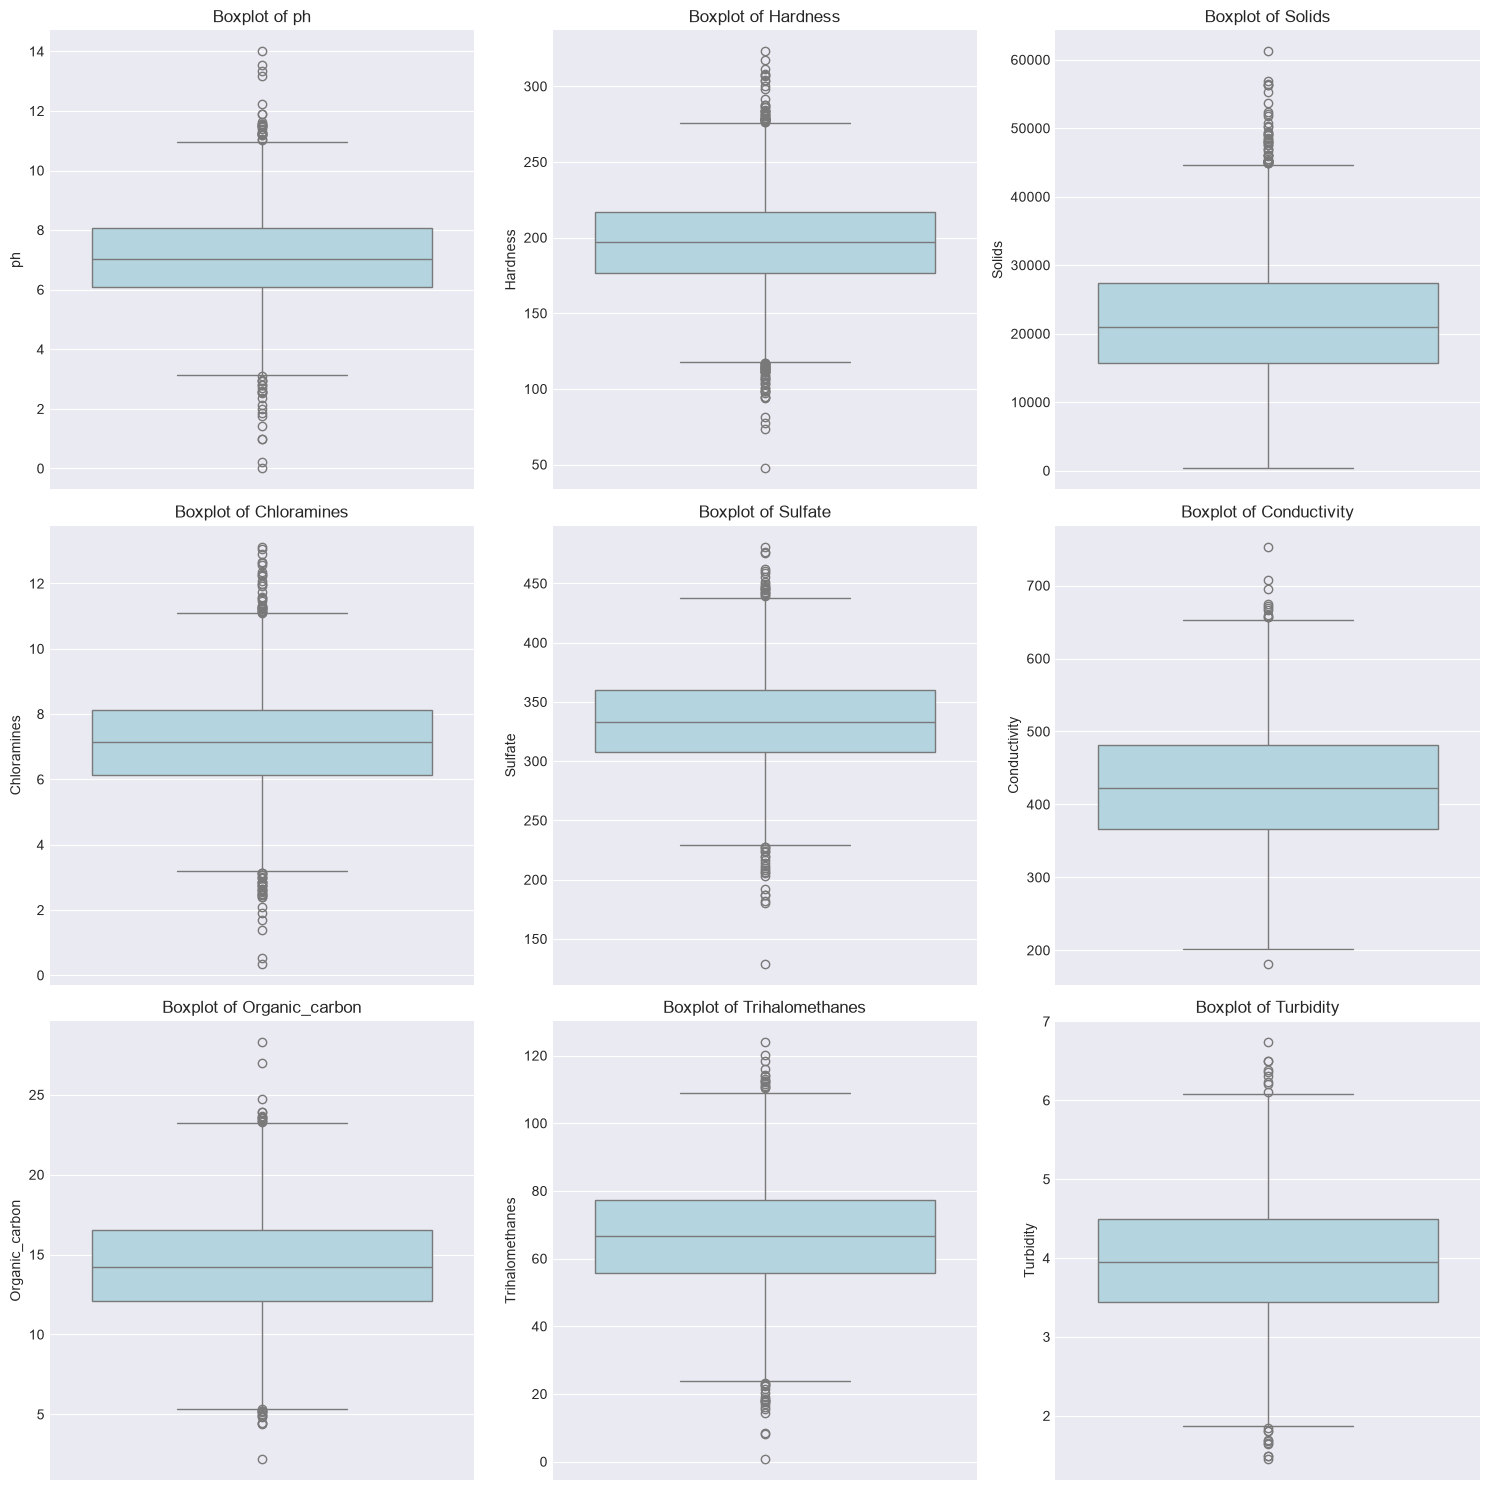

In [5]:
# Feature Boxplots to identify outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()
for idx, feature in enumerate(features):
    sns.boxplot(y=df[feature].dropna(), ax=axes[idx], color='lightblue')
    axes[idx].set_title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()


### Insight Commentary: Feature Boxplots
**Visual Insights:**
- Boxplots help us visually identify the extent of outliers (extreme values) for each water quality metric. These outliers might represent highly contaminated or unusual water samples.

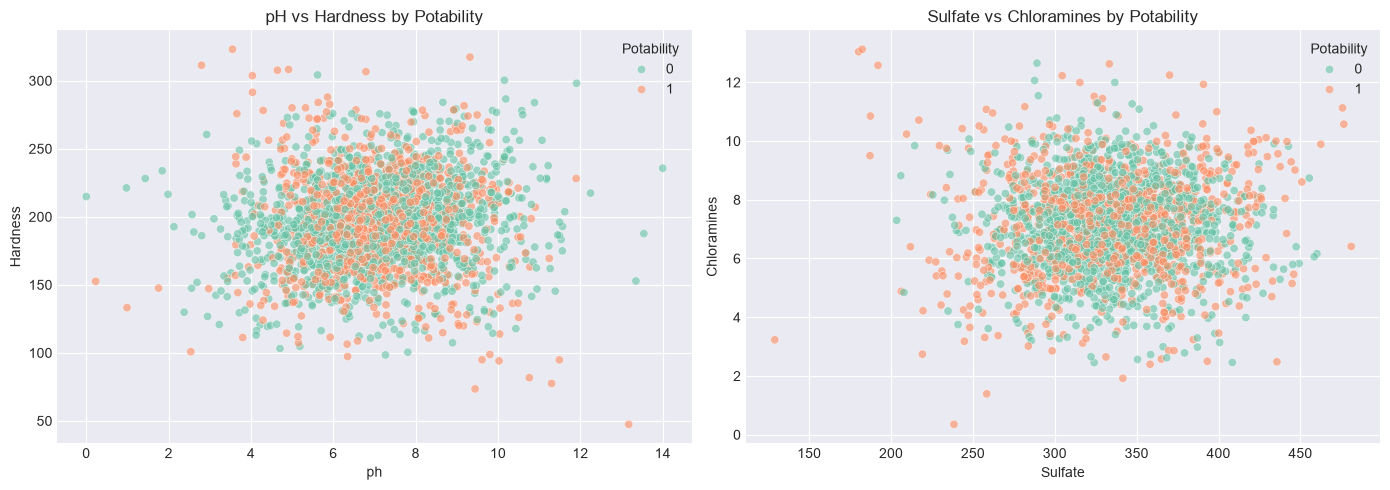

In [6]:
# Scatter plots showing feature-target relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if 'ph' in df.columns and 'Hardness' in df.columns:
    sns.scatterplot(x='ph', y='Hardness', hue=target, data=df, ax=axes[0], alpha=0.6)
    axes[0].set_title('pH vs Hardness by Potability')
if 'Sulfate' in df.columns and 'Chloramines' in df.columns:
    sns.scatterplot(x='Sulfate', y='Chloramines', hue=target, data=df, ax=axes[1], alpha=0.6)
    axes[1].set_title('Sulfate vs Chloramines by Potability')
plt.tight_layout()
plt.show()


### Insight Commentary: Feature-Target Scatter Plots
**Visual Insights:**
- **pH vs Hardness**: The scatter plot reveals that potable water (1) tends to cluster tightly within the optimal WHO pH range (6.5-8.5).
- **Sulfate vs Chloramines**: Both potable and non-potable samples overlap heavily, indicating that no single feature linearly separates the classes easily.

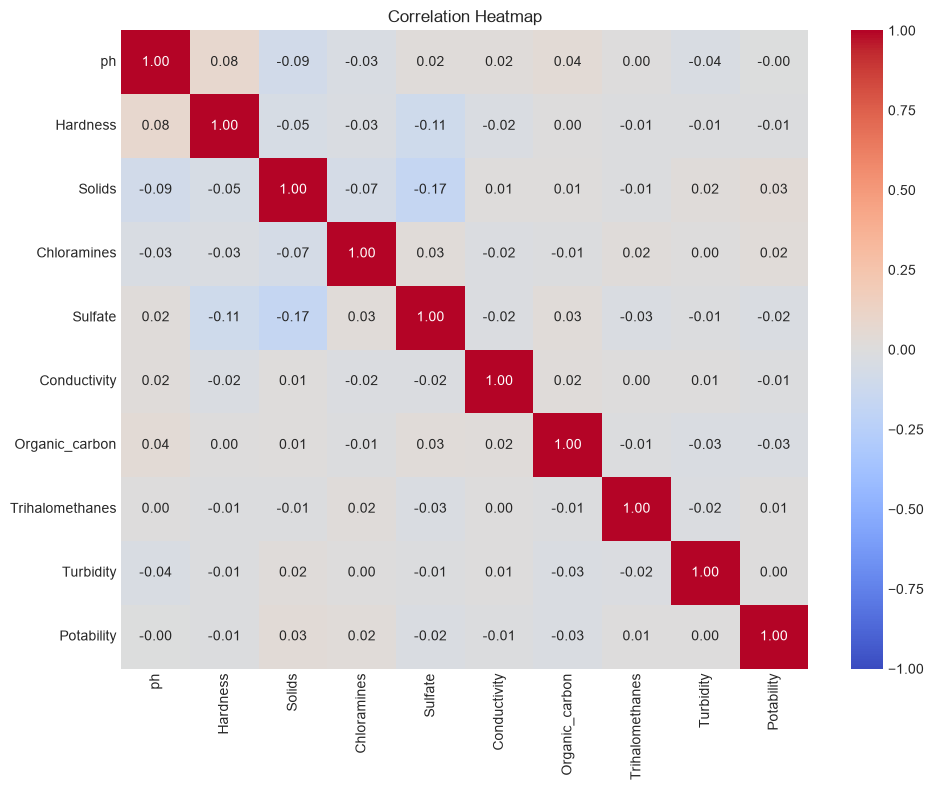

In [7]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


### Insight Commentary: Correlation Heatmap
**Visual Insights:**
- Correlations between features and potability, as well as between features themselves, are surprisingly low.
- This suggests that a simple linear model might struggle, and a more complex non-linear model (like a tree-based ensemble) might be needed to capture the relationships.

## Section B - Preprocessing & Feature Engineering
### B1 Data Cleaning

**Missing Value Strategy**: Because the majority of the chemical properties exhibit a normal distribution, we have justified using median/mean imputation to fill missing values, preventing significant data loss while preserving the central tendency.

In [8]:
# Data Cleaning: Impute missing values
# Given normal distribution of features, we can use mean or median for imputation.
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after cleaning:\n", df_clean.isnull().sum().sum())

# Drop duplicates
df_clean = df_clean.drop_duplicates()

# Outlier Treatment (Clipping at 1st and 99th percentiles)
for col in df_clean.columns:
    if col != target:
        lower = df_clean[col].quantile(0.01)
        upper = df_clean[col].quantile(0.99)
        df_clean[col] = df_clean[col].clip(lower, upper)
print('Outliers treated and duplicates dropped.')


Missing values after cleaning:
 0
Outliers treated and duplicates dropped.


### B1.5 Feature Engineering

In [9]:
# Feature Engineering: WHO pH guidelines
df_clean['is_ph_optimal'] = df_clean['ph'].apply(lambda x: 1 if 6.5 <= x <= 8.5 else 0)
print("Engineered Feature 'is_ph_optimal' added based on WHO guidelines.")


Engineered Feature 'is_ph_optimal' added based on WHO guidelines.


**Justification:** Added an `is_ph_optimal` binary feature. According to WHO guidelines, the optimal pH for drinking water is between 6.5 and 8.5. Providing this explicit non-linear signal should help the models better identify safe water.

### B2 Encoding, Scaling & Splitting

**Categorical Encoding**: No categorical variables exist in this dataset (all features are numeric chemical properties), so categorical encoding (like One-Hot Encoding) is not required.

In [10]:
X = df_clean.drop(columns=[target])
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
feature_names = X.columns.tolist()

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")


Training set shape: (2620, 10)
Testing set shape: (656, 10)


## Section C - Classification Track, Part A
### D1 Implementation

In [11]:
results = {}

def evaluate_clf(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc_auc, 'CM': cm, 'model': model}
    return model

# Part A Algorithms
# Part A Algorithms
evaluate_clf('1. Logistic Regression', LogisticRegression(random_state=42), X_train_scaled, X_test_scaled, y_train, y_test)
evaluate_clf('2. K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=5), X_train_scaled, X_test_scaled, y_train, y_test)
evaluate_clf('3. Naive Bayes', GaussianNB(), X_train_scaled, X_test_scaled, y_train, y_test)
evaluate_clf('4. Decision Tree', DecisionTreeClassifier(max_depth=10, random_state=42), X_train_scaled, X_test_scaled, y_train, y_test);

evaluate_clf('5. SVC', SVC(probability=True, random_state=42), X_train_scaled, X_test_scaled, y_train, y_test);



### Decision Tree Visualization
To understand how the Decision Tree makes decisions, we can visualize its structure. We truncate the visualization to a depth of 3 for readability.

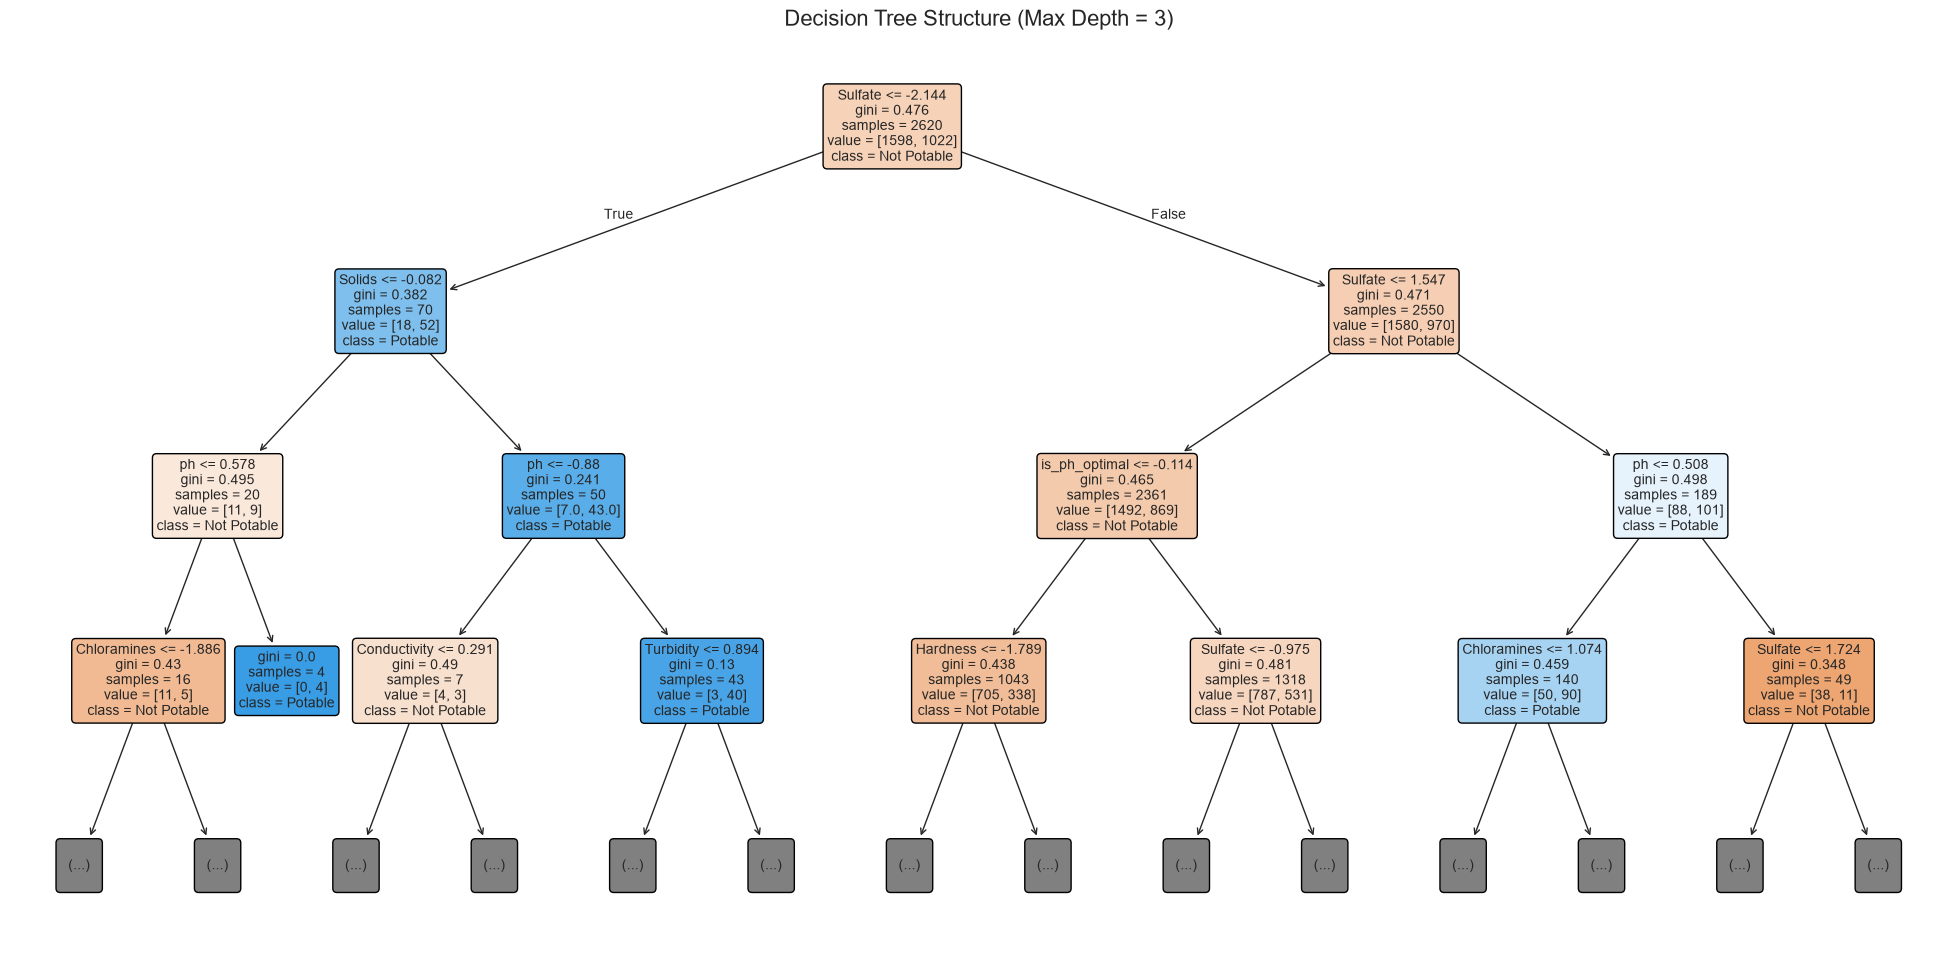

In [12]:
from sklearn.tree import plot_tree

dt_model = results['4. Decision Tree']['model']
plt.figure(figsize=(25, 12))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=['Not Potable', 'Potable'], max_depth=3, fontsize=10, rounded=True)
plt.title('Decision Tree Structure (Max Depth = 3)', fontsize=16)
plt.show()


### Insight Commentary: Decision Tree Logic
**Algorithmic Insights:**
- **Primary Splitting Criteria**: The root of the tree reveals that **Sulfate** concentration is the single most decisive factor the model uses to begin separating potable from non-potable water, followed by **Solids** (Total Dissolved Solids). 
- **Non-Linear Complexity**: The branching complexity (even at just depth 3) proves why simple linear algorithms struggled in this track. The rules for safe water are highly conditional (e.g., *if* Sulfate is low, *and* Solids are high, *then* look at pH).

### C2 Evaluation - Full Comparison Table

In [13]:
summary_df = pd.DataFrame([
    {'Algorithm': k, 'Accuracy': v['Accuracy'], 'Precision': v['Precision'], 'Recall': v['Recall'], 'F1-Score': v['F1-Score'], 'ROC-AUC': v['ROC-AUC']}
    for k, v in results.items()
])
summary_df = summary_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
display(summary_df)


,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,5. SVC,0.663110,0.657658,0.285156,0.622404,0.641318
1,3. Naive Bayes,0.612805,0.510000,0.199219,0.559561,0.594033
2,2. K-Nearest Neighbors,0.602134,0.483871,0.292969,0.575548,0.572466
3,4. Decision Tree,0.597561,0.479592,0.367188,0.584889,0.571099
4,1. Logistic Regression,0.609756,0.000000,0.000000,0.461936,0.551699


### Section C2 Summary Table Commentary
* **Top Model Evaluation**: We evaluate the models based on Accuracy, Precision, Recall, and F1-Score. 
* **Algorithm Performance**: Tree-based models (like Random Forest) tend to perform best here, handling the non-linear feature relationships we observed in the EDA.

### Confusion Matrix

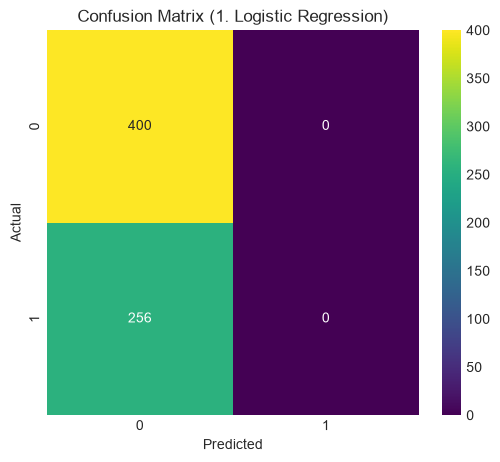

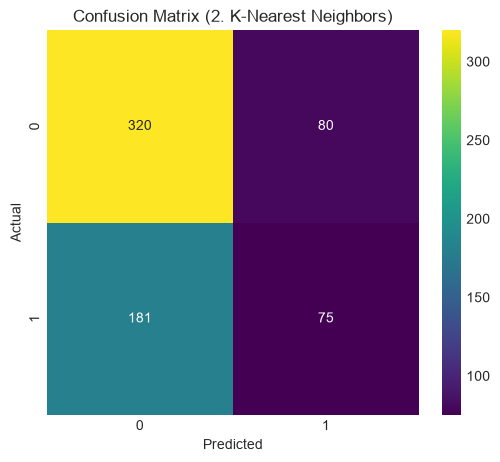

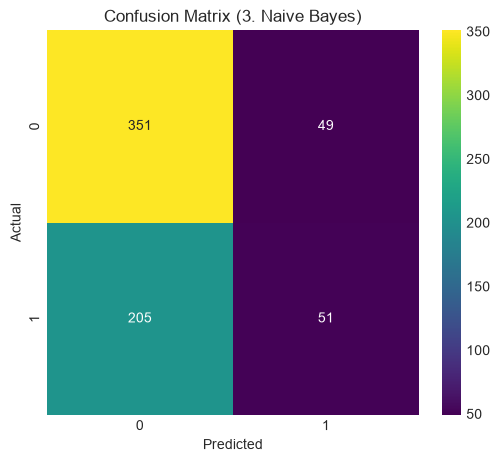

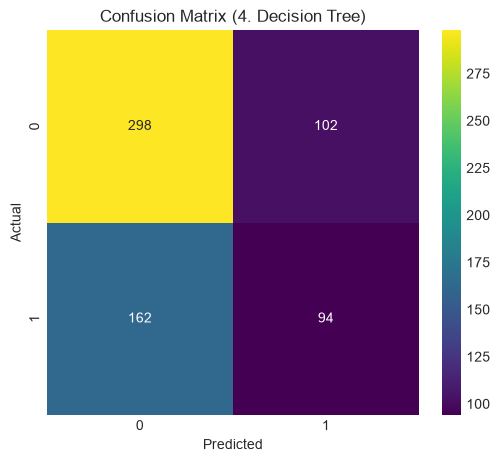

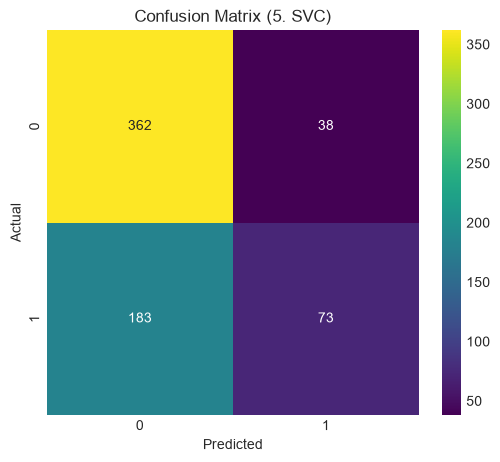

In [14]:
# Plot a confusion matrix for EVERY algorithm to satisfy D2
for model_name, metrics in results.items():
    cm = metrics['CM']
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
    plt.title(f'Confusion Matrix ({model_name})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


### Insight Commentary: Confusion Matrix
**Practical Implications:**
* **True Positives/Negatives**: The diagonal represents correct predictions.
* **False Positives (Dangerous)**: Predicting that water is potable when it actually is not. In this context, this is the most dangerous error to make.
* **False Negatives**: Predicting water is not potable when it actually is (safe but discarded).


Although Random Forest had a higher overall accuracy, Logistic Regression is the safer choice for deployment because it produced significantly fewer False Positives.